### **MANUAL CODE**

**Recommendation**: start an instance of 20GB for this notebook to work on case1 and 15GB is enough to work for case2 (case1 and case2 are defined below)

In [1]:
import pandas as pd
import pyranges as pr
from scipy.stats import ttest_ind
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math
%reload_ext memory_profiler

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
def load_whole_gtf(gtf_file):
    columns = ["Chromosome", "Source", "Feature", "Start", "End", "Score", "Strand", "Frame", "Attribute"]
    gtf = pd.read_csv(gtf_file, sep="\t", comment="#", names=columns)
    gtf["Chromosome"] = gtf["Chromosome"].astype(str)
    return gtf[["Chromosome", "Feature","Start", "End", "Strand", "Attribute"]]

In [4]:
def load_motif_fastaregexfinder_results(motif_file):
    columns = ["Chromosome", "Start", "End", "Motif_name", "Strand", "Motif_Matched"]
    motifs = pd.read_csv(motif_file, sep="\t", names=columns)
    motifs["second_idx"] = range(1, len(motifs) + 1)
    return motifs

In [5]:
def filter_motif(motif_df):
    resolved_chr = [f'chr{i}' for i in range(1,25+1)]
    resolved_chr.append('chrM')
    return motif_df[motif_df["Chromosome"].isin(resolved_chr)]

In [6]:
# Scaffolds decrease confidence, we filter them out
def filter_gtf(gtf_df):
    resolved_chr = [f'chr{i}' for i in range(1,25+1)]
    resolved_chr.append('chrM')
    return gtf_df[gtf_df["Chromosome"].isin(resolved_chr)]

In [7]:
def get_percentage(part, whole):
    return 100 * float(part)/float(whole)

**Lawson Files Loading**

In [8]:
# Load data
gtf_file = "/path_to_Reference/Zebrafish/LawsonData/V4.3.2.validated.gtf" 
#fastaregexfinder
motif_file_fastaregex = "../DCM_motifs_in_Genome/Danio_rerio/Lawson/dcm_motifs_zero_based.bed" #if I use the one_based then the overlap in inclusion is max 4 and this is not great

#chr lengths file
chr_lengths = pd.read_csv("/path_to_Reference/Zebrafish/LawsonData/V4.3.2.validated_chr_lengths.txt",sep='\t',names=['Chromosome', 'Length'], header=None)
#genes lengths file
lawson_genes_lengths = pd.read_csv("/path_to_Reference/Zebrafish/LawsonData/V4.3.2.validated_gene_lengths.txt",sep='\t',names=['Chromosome','Length','gene_id','custom_gene_id'],header=None)

#Case1: a motif found on a strand also belongs to genes encoded on the opposite strand
#Case2: a motif found on a strand only belongs to genes encoded on its strand
case="case2"

### Enrichment Analysis

In [9]:
if case=='case1':
    genome_length=1345118429 #found from the terminal dealing with the fasta assembly
    strand=False
    strandedness_=False
elif case=="case2":
    genome_length=1345118429*2
    strand=True
    strandedness_='same'
else:
    raise NameError('Provide a case number')

features = filter_gtf(load_whole_gtf(gtf_file))

Text(0.5, 1.0, 'Proportion of Genes and Intergenic regions inside \nthe genome, as annotated by Lawson')

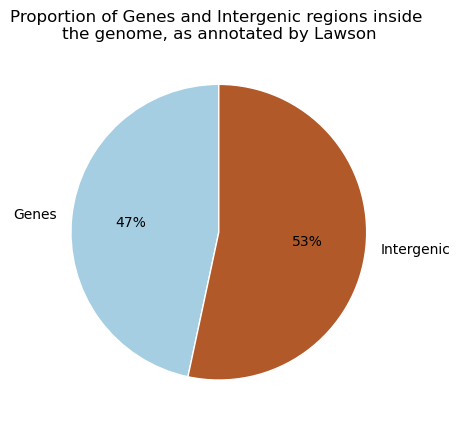

In [10]:
#enrichment in genes vs intergenic

genes_=features[features['Feature']=='gene']
genes=pr.PyRanges(genes_)
#find the length of all genes, removing overlapping parts
genes_lengths=genes.merge(strand).length

intergenic_lengths = genome_length - genes_lengths

percent_genic=round(get_percentage(genes_lengths,genome_length),2)
percent_intergenic= round(get_percentage(intergenic_lengths,genome_length),2)

fig, ax = plt.subplots()
percentage=[percent_genic,percent_intergenic]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Genes","Intergenic"], autopct='%1.0f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title('Proportion of Genes and Intergenic regions inside \nthe genome, as annotated by Lawson')

Text(0.5, 1.0, 'Proportion of transcripts and "outside transcripts" \nregions inside the genome, as annotated by Lawson')

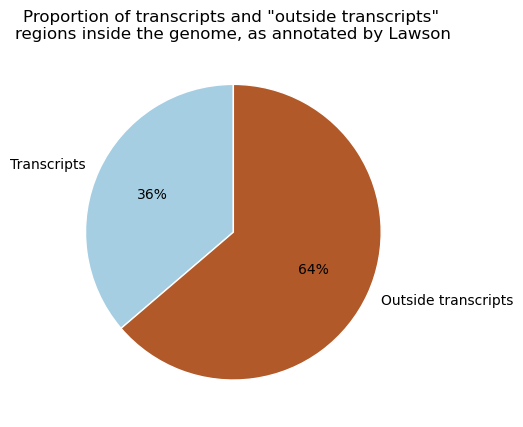

In [11]:
#enrichment in transcripts vs. intertranscripts

transcripts_ = features[features['Feature']=='transcript']
transcripts=pr.PyRanges(transcripts_)
length_transcripts = transcripts.merge(strand).length

length_intertranscripts = genome_length - length_transcripts

percent_transcripts = round(get_percentage(length_transcripts,genome_length),2)
percent_intertranscripts = round(get_percentage(length_intertranscripts,genome_length),2)

fig, ax = plt.subplots()
percentage=[percent_transcripts,percent_intertranscripts]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Transcripts","Outside transcripts"], autopct='%1.0f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title('Proportion of transcripts and "outside transcripts" \nregions inside the genome, as annotated by Lawson')

Text(0.5, 1.0, 'Proportion of exonic and intronic regions inside \nthe transcriptome, as annotated by Lawson')

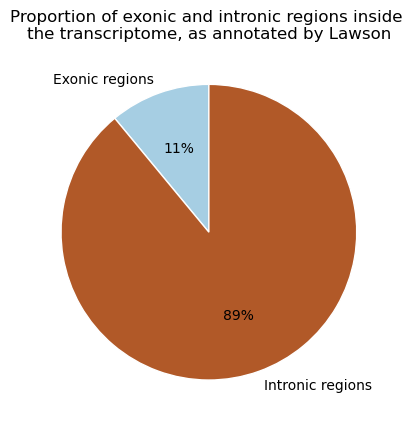

In [12]:
#enrichment in exons vs. introns

transcripts_=features[features['Feature']=='transcript']
exons_=features[features['Feature']=='exon']

transcripts=pr.PyRanges(transcripts_)
transcripts_length=transcripts.merge(strand).length

exons=pr.PyRanges(exons_)
exons_length=exons.merge(strand).length

introns_length=transcripts_length-exons_length

percent_exons=round(get_percentage(exons_length,transcripts_length),2)
percent_introns=round(get_percentage(introns_length,transcripts_length),2)

fig, ax = plt.subplots()
percentage=[percent_exons,percent_introns]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Exonic regions","Intronic regions"], autopct='%1.0f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title('Proportion of exonic and intronic regions inside \nthe transcriptome, as annotated by Lawson')

### **Motifs Annotation**

In [13]:
# Step1: find the motifs present in a gene
## homer
#motifs = load_motif_homer_results(motif_file_homer)

## fastaregexfinder
motifs = load_motif_fastaregexfinder_results(motif_file_fastaregex)
# remove scaffolds to increase confidence
motifs = filter_motif(motifs)

features = load_whole_gtf(gtf_file)
features = filter_gtf(features)

## look only at features that are genes here
features_genes=features[features["Feature"]=="gene"]
motifs_ranges = pr.PyRanges(motifs)
features_genes_ranges = pr.PyRanges(features_genes)
inclusion_annotation = motifs_ranges.join(features_genes_ranges, strandedness_, how='containment',report_overlap=True)
inclusion_annotation = inclusion_annotation.df[inclusion_annotation.df["Overlap"]>=5]
# Create a boolean mask based on the condition
mask = motifs["second_idx"].isin(
    motifs_ranges.df["second_idx"][motifs_ranges.df["second_idx"].isin(inclusion_annotation["second_idx"])]
)
# Assign the mask to the "inside_gene" column
motifs["inside_gene"] = mask

# Step2: subset the whole motifs to keep only those present in a gene
motifs_genes=motifs[motifs["inside_gene"]==True]

# Step3: consider only those motifs found in at least a gene and look in the annotation in which other feature these motifs are found
motifs_genes_ranges = pr.PyRanges(motifs_genes)
#look at all features now
features_ranges = pr.PyRanges(features)
inclusion_gene = motifs_genes_ranges.join(features_ranges, strandedness_, how='containment',report_overlap=True)
inclusion_gene = inclusion_gene.df[inclusion_gene.df["Overlap"]>=5]
inclusion_gene

# Filter inclusion_gene for rows with "transcript" in the Feature column
transcript_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "transcript", "second_idx"]
# Create a boolean mask based on the condition: true if second idx of motifs found in genes is in the transcript indices
mask = motifs_genes["second_idx"].isin(transcript_indices)
# Assign the mask to the "inside_transcript" column
motifs_genes["inside_transcript"] = mask


# 5' UTR
five_prime_utr_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "five_prime_utr", "second_idx"]
mask = motifs_genes["second_idx"].isin(five_prime_utr_indices)
motifs_genes["inside_five_prime_utr"] = mask

# 3' UTR
three_prime_utr_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "three_prime_utr", "second_idx"]
mask = motifs_genes["second_idx"].isin(three_prime_utr_indices)
motifs_genes["inside_three_prime_utr"] = mask

#CDS
CDS_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "CDS", "second_idx"]
mask = motifs_genes["second_idx"].isin(CDS_indices)
motifs_genes["inside_CDS"] = mask

#exon
exon_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "exon", "second_idx"]
mask = motifs_genes["second_idx"].isin(exon_indices)
motifs_genes["inside_exon"] = mask

motifs_genes.head()

,Chromosome,Start,End,Motif_name,Strand,Motif_Matched,second_idx,inside_gene,inside_transcript,inside_five_prime_utr,inside_three_prime_utr,inside_CDS,inside_exon
23,chr1,9992,9997,chr1_9992_9997_rev,-,CCTGG,24,True,True,False,False,False,False
25,chr1,10852,10857,chr1_10852_10857_rev,-,ccagg,26,True,True,False,False,False,False
26,chr1,11561,11566,chr1_11561_11566_rev,-,CCTGG,27,True,True,False,False,False,True
28,chr1,11951,11956,chr1_11951_11956_for,+,CCTGG,29,True,True,False,False,False,True
29,chr1,11951,11956,chr1_11951_11956_rev,-,CCTGG,30,True,True,False,False,False,True


### **Motifs distribution in chromosomes and genes, and outliers removing**

Scaffolds were removed when loading the annotation to increase confidence. I've noted they only contained very few motifs, which much probably were found by chance.

**Motifs distribution in chromosomes**

In [14]:
# In which chromosomes are found the motifs present inside genes?
tmp=pd.DataFrame(inclusion_annotation["Chromosome"].value_counts())
tmp=tmp.rename(columns={'count':'Nb of "inside genes" DCM motifs for each chr'}).reset_index()
tmp['Chromosome']=tmp['Chromosome'].astype(str)
tmp_merged = tmp.merge(chr_lengths)
tmp_merged['count_normalized']=tmp_merged['Nb of "inside genes" DCM motifs for each chr']/tmp_merged['Length']
tmp_merged.head()

,Chromosome,"Nb of ""inside genes"" DCM motifs for each chr",Length,count_normalized
0,chr4,2553740,1595912546,0.001600
1,chr3,187415,171505699,0.001093
2,chr7,104791,96803793,0.001083
3,chr5,99224,96047212,0.001033
4,chr11,87311,84358279,0.001035


<Figure size 2000x1000 with 0 Axes>

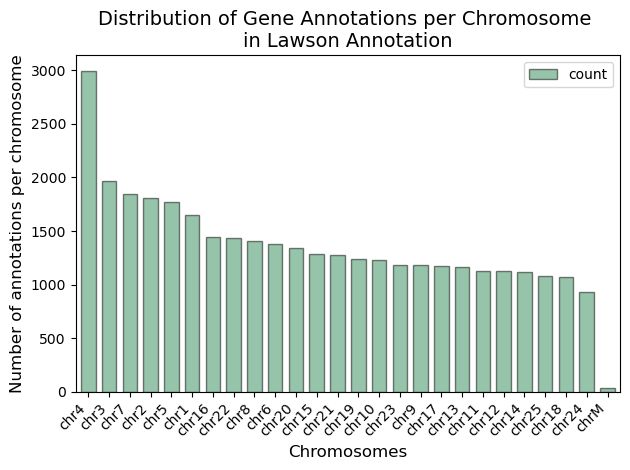

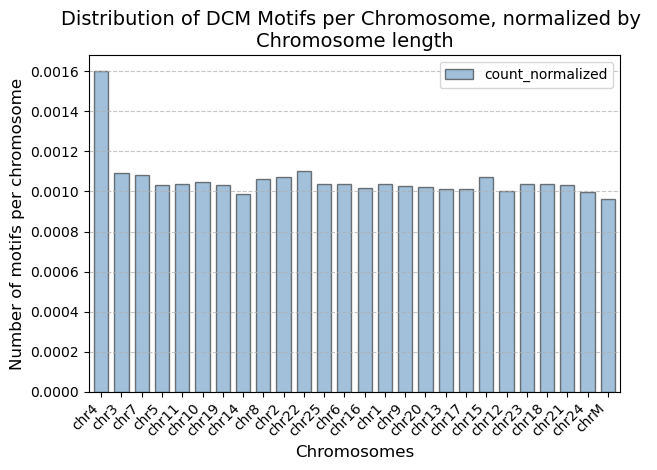

In [15]:
# Plot distribution
plt.figure(figsize=(20, 10))

# Distribution of genes annotated in Lawson annotation
tmp_=pd.DataFrame(features_genes_ranges.df["Chromosome"].value_counts())
tmp_.plot(kind='bar', color='seagreen', edgecolor='black', width=0.7, alpha=0.5)
plt.xlabel('Chromosomes', fontsize=12)
plt.ylabel('Number of annotations per chromosome', fontsize=12)
plt.title('Distribution of Gene Annotations per Chromosome \nin Lawson Annotation', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# Distribution of DCM motifs in Lawson annotation
#tmp_merged['count_normalized'].plot(kind='bar', color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
tmp_merged.plot.bar(x='Chromosome',y='count_normalized', color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
plt.xlabel('Chromosomes', fontsize=12)
plt.ylabel('Number of motifs per chromosome', fontsize=12)
plt.title('Distribution of DCM Motifs per Chromosome, normalized by \nChromosome length', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We have lots more motifs on chr4, but it correlates with a higher nb of genes being annotated on chr4.

**Motifs distribution in genes**

In [16]:
# Distribution of the nb of motifs per gene
df = inclusion_annotation
df['custom_gene_id'] = df['Chromosome'].astype(str) + ':' + df['Start_b'].astype(str) + '-' + df['End_b'].astype(str) + ':' + df['Strand_b'].astype(str)
gene_motifs_count = df.groupby('custom_gene_id')['second_idx'].nunique().reset_index(name='motif_count')
gene_motifs_count=lawson_genes_lengths.merge(gene_motifs_count)
gene_motifs_count['normalized_count']=gene_motifs_count['motif_count']/gene_motifs_count['Length']

Do the genes with high number of motifs tend to belong to chromosome 4?

Text(0.5, 1.0, 'Distribution of the chromosomes on which genes with a number \nof motifs superior to the 75% quantile are found')

<Figure size 3000x1000 with 0 Axes>

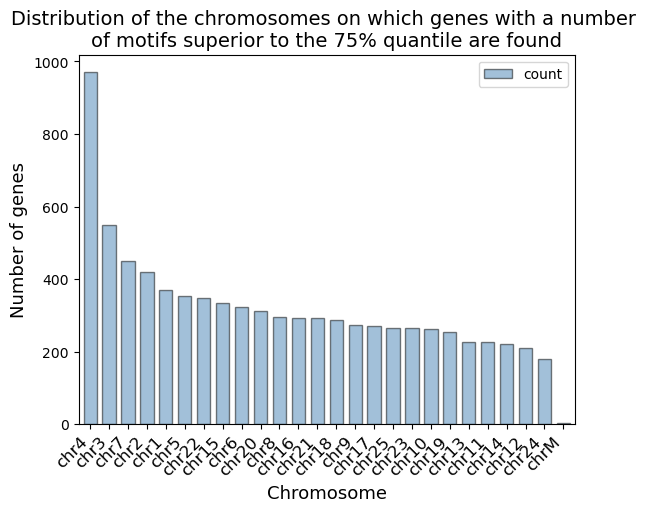

In [17]:
upper_quantile=gene_motifs_count.normalized_count.quantile(0.75)
chr_=gene_motifs_count.loc[gene_motifs_count['normalized_count']>upper_quantile,'Chromosome']
chr_values=chr_.value_counts()
chr_values_df=pd.DataFrame(chr_.value_counts()).reset_index('Chromosome')
plt.figure(figsize=(30, 10))
chr_values_df.plot.bar(x='Chromosome',y='count',color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
plt.xlabel('Chromosome',fontsize=13)
plt.ylabel('Number of genes',fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title('Distribution of the chromosomes on which genes with a number \nof motifs superior to the 75% quantile are found',fontsize=14)

Yes genes having the highest number of motifs per genes tend to fall more on chr4

Distribution of the number of motifs per gene, NOT normalized by the genes lengths

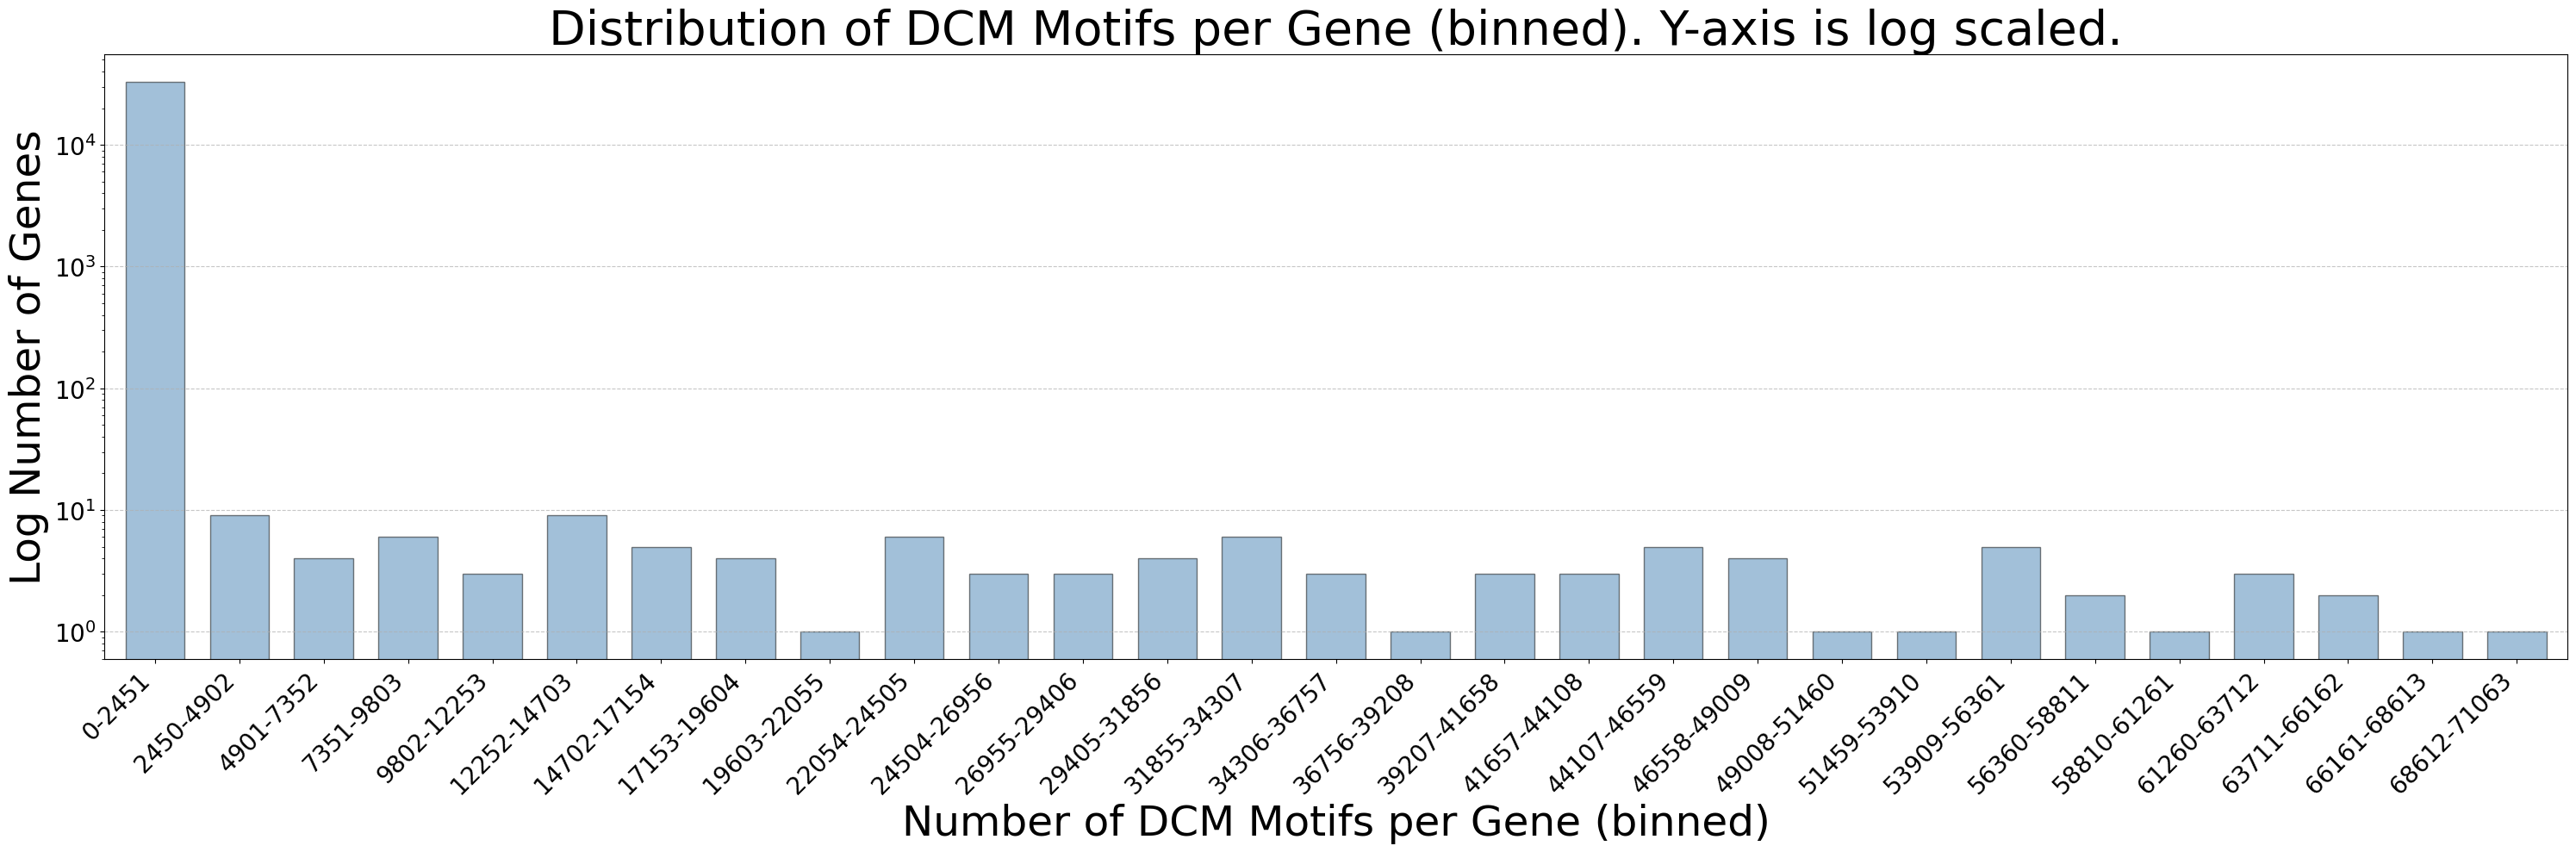

In [18]:
distribution = gene_motifs_count['motif_count'].value_counts().sort_index()
distribution_df = pd.DataFrame([distribution]).T.reset_index() 
distribution_df = distribution_df.rename(columns={'motif_count' : 'nb_of_motifs_per_gene', 'count' : 'nb_of_genes'})
distribution_df

bins = np.linspace(0,max(distribution_df['nb_of_motifs_per_gene']),30)
bins = np.round(bins, 0)
bins = bins.astype(int)
labels = [f"{bins[i]}-{bins[i+1]+1}" for i in range(len(bins)-1)]
distribution_df['bin'] = pd.cut(distribution_df['nb_of_motifs_per_gene'], bins=bins, labels=labels, right=True)
binned_distribution = distribution_df.groupby('bin')['nb_of_genes'].sum()

plt.figure(figsize=(30, 10))
binned_distribution.plot.bar(color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
plt.title('Distribution of DCM Motifs per Gene (binned). Y-axis is log scaled.', fontsize=40)
plt.ylabel('Log Number of Genes', fontsize=35)
plt.xlabel('Number of DCM Motifs per Gene (binned)', fontsize=35)
plt.yscale('log')
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Distribution of the number of motifs per gene normalized by the genes lengths

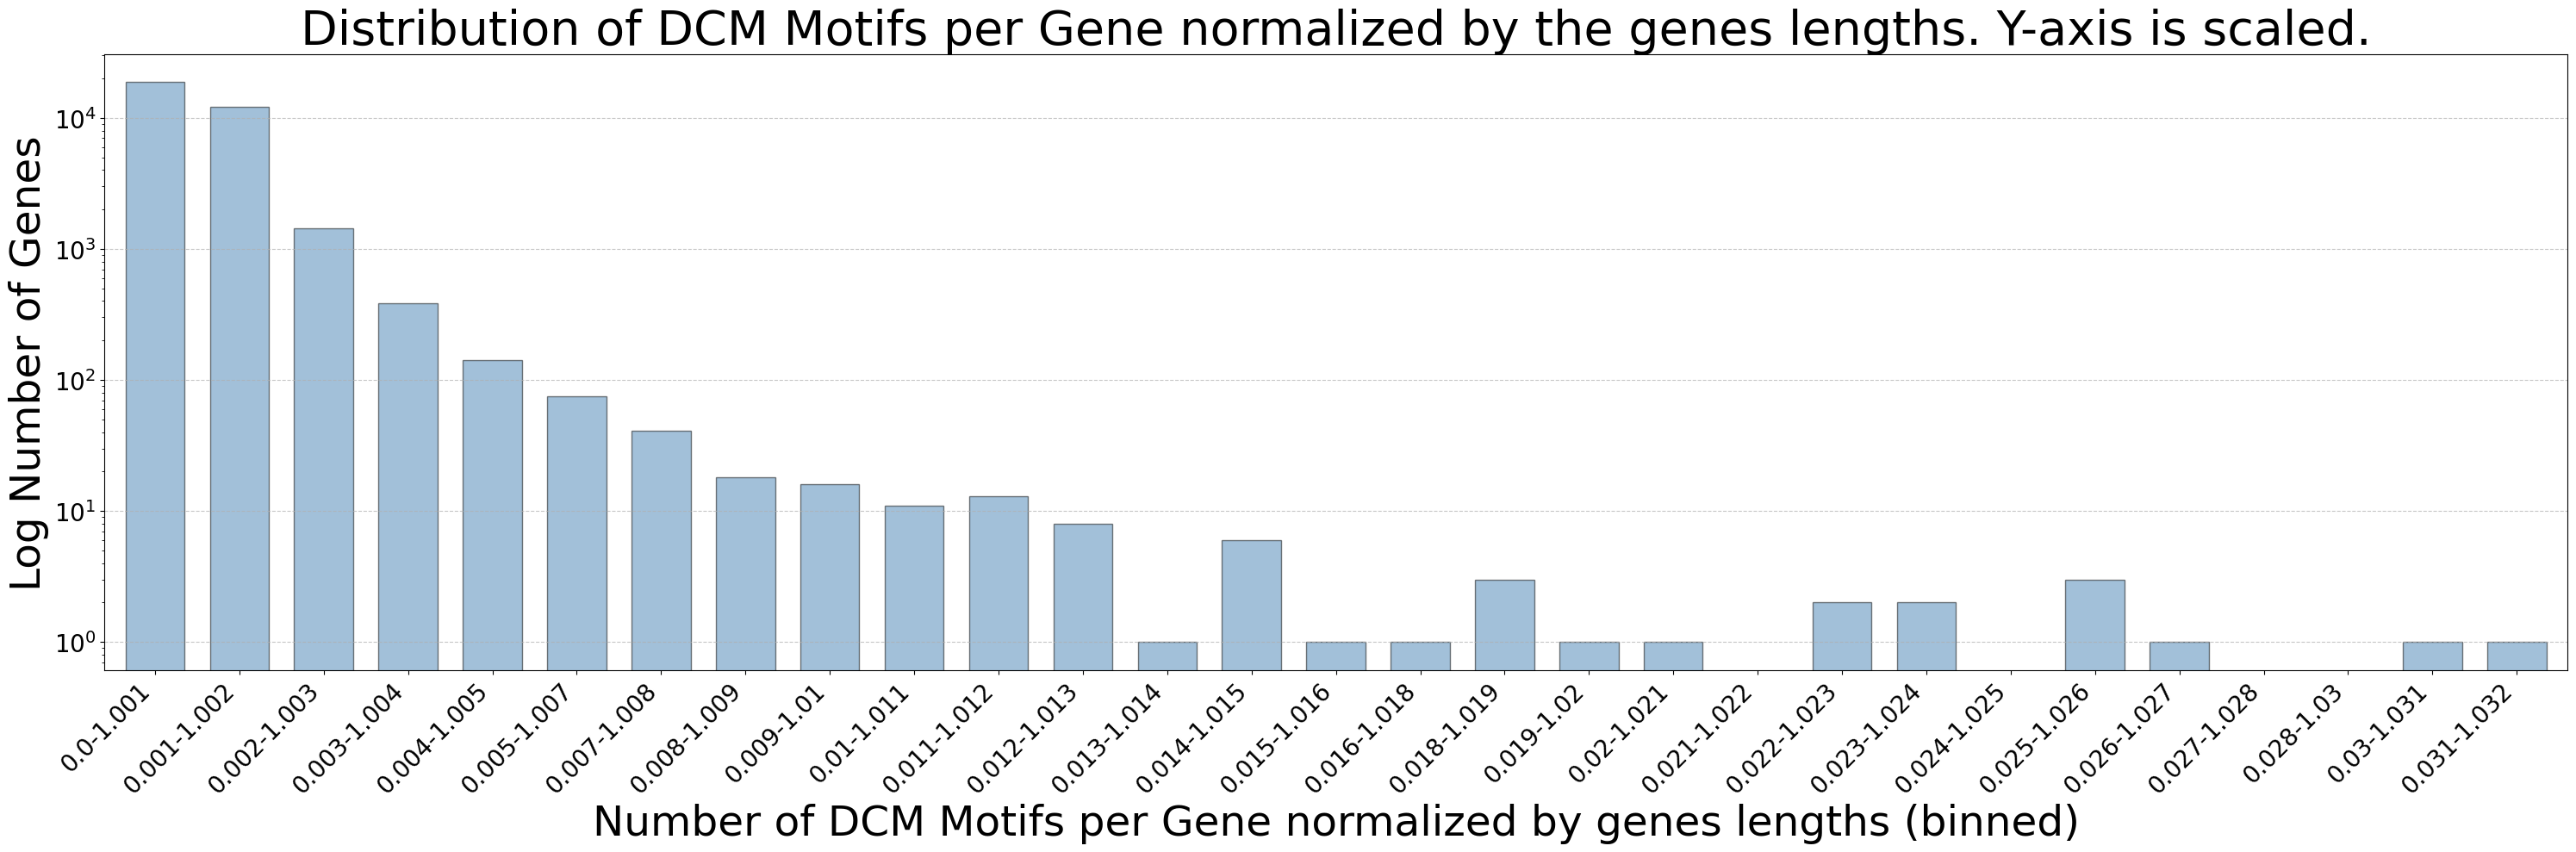

In [19]:
distribution_normalized = gene_motifs_count['normalized_count'].value_counts().sort_index()
distribution_normalized_df = pd.DataFrame([distribution_normalized]).T.reset_index() 
distribution_normalized_df = distribution_normalized_df.rename(columns={'normalized_count' : 'normalized_nb_of_motifs_per_gene', 'count' : 'nb_of_genes'})

bins = np.linspace(0,max(distribution_normalized_df['normalized_nb_of_motifs_per_gene']),30)
#bins = np.round(bins, 0)
labels = [f"{round(bins[i],3)}-{round(bins[i+1]+1,3)}" for i in range(len(bins)-1)]
distribution_normalized_df['bin'] = pd.cut(distribution_normalized_df['normalized_nb_of_motifs_per_gene'], bins=bins, labels=labels, right=True)
binned_distribution = distribution_normalized_df.groupby('bin')['nb_of_genes'].sum()

plt.figure(figsize=(30, 10))
binned_distribution.plot.bar(color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
plt.title('Distribution of DCM Motifs per Gene normalized by the genes lengths. Y-axis is scaled.', fontsize=40)
plt.ylabel('Log Number of Genes', fontsize=35)
plt.xlabel('Number of DCM Motifs per Gene normalized by genes lengths (binned)', fontsize=35)
plt.yscale('log')
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Compute all proportions**

In [20]:
print(f"We detect DCM motifs in {df['custom_gene_id'].nunique()} unique genes \n(there are 36'351 annotated genes in Lawson)")


We detect DCM motifs in 32977 unique genes 
(there are 36'351 annotated genes in Lawson)


In [21]:
print(f"The mean of the number of motifs per gene is {round(distribution_df['nb_of_motifs_per_gene'].mean(),2)}")
print(f"with a huge std of {round(distribution_df['nb_of_motifs_per_gene'].std(),2)}")

The mean of the number of motifs per gene is 4970.74
with a huge std of 13051.02


In [22]:
#% of motifs inside genes:
percent_inside_gene = round(get_percentage(len(motifs_genes),len(motifs)))
percent_intergenic = round(get_percentage(len(motifs)-len(motifs_genes),len(motifs)))
print("Percentage of motifs found in at least one gene: {0}, Percentage of motifs not found in any gene: {1}".format(percent_inside_gene,percent_intergenic))

Percentage of motifs found in at least one gene: 47, Percentage of motifs not found in any gene: 53


In [23]:
#% of motifs appearing in more than one gene

nb_duplicated_motifs = len(inclusion_annotation[(inclusion_annotation['second_idx'].duplicated())==True])
nb_unique_motifs = len(inclusion_annotation[(inclusion_annotation['second_idx'].duplicated())==False])

## Distinct genes correspond to the same motif:
percent_duplicated_occurrences = round(get_percentage(nb_duplicated_motifs,len(inclusion_annotation)),2)
percent_unique_occurrences = round(get_percentage(nb_unique_motifs,len(inclusion_annotation)),2)

## A motif might correspond to distinct genes:
duplicated_values = inclusion_annotation["second_idx"][inclusion_annotation["second_idx"].duplicated()]
duplicates_in_motifs_genes = motifs_genes["second_idx"].isin(duplicated_values)
count_duplicates = duplicates_in_motifs_genes.sum()
percent_duplicated_motifs = round(get_percentage(count_duplicates,len(motifs_genes)),2)

print(f"Out of all the matches between a DCM motif and a position in the genome ({len(inclusion_annotation)}), {nb_unique_motifs} correspond to a unique motif while {nb_duplicated_motifs} correspond to motifs matching several positions")
print(f"In other words, {percent_duplicated_occurrences} % of positions in the genome for which a match with a DCM motif was found, correspond to motifs matching several positions")
print(f"In other words, {percent_unique_occurrences} % of positions in the genome for which a match with a DCM motif was found, correspond to motifs matching a unique position")
print(f"In the other way around, {percent_duplicated_motifs} % of our motifs are found in several genes in the genome")

Out of all the matches between a DCM motif and a position in the genome (3978089), 1359621 correspond to a unique motif while 2618468 correspond to motifs matching several positions
In other words, 65.82 % of positions in the genome for which a match with a DCM motif was found, correspond to motifs matching several positions
In other words, 34.18 % of positions in the genome for which a match with a DCM motif was found, correspond to motifs matching a unique position
In the other way around, 26.09 % of our motifs are found in several genes in the genome


**Gene Motifs found in at least one transcript vs. in no transcript i.e. in intronic part found between two non-overlapping transcripts of a gene**

In [24]:
nb_motifs_inside_transcripts = len(motifs_genes[motifs_genes["inside_transcript"]==True])

percent_inside_transcript = round(get_percentage(nb_motifs_inside_transcripts,len(motifs_genes)),3)
percent_outside_transcript = round(get_percentage(len(motifs_genes)-nb_motifs_inside_transcripts,len(motifs_genes)),3)

print("Percentage of motifs present in genes that are found in at least one transcript: {0} \nPercentage of motifs present in genes that are not found in any transcript (=intronic part between two non-overlapping transcripts): {1} %".format(percent_inside_transcript,percent_outside_transcript))

Percentage of motifs present in genes that are found in at least one transcript: 73.248 
Percentage of motifs present in genes that are not found in any transcript (=intronic part between two non-overlapping transcripts): 26.752 %


In [25]:
print("More precisely, {0} motifs that are present in at least one gene were not found in any transcript, knowing there are {1} motifs found in at least one gene".format(len(motifs_genes[motifs_genes["inside_transcript"]==False]),len(motifs_genes)))
print("These motifs correspond to motifs falling the type of intronic regions that are found between two non-overlapping transcripts in a gene")

More precisely, 363727 motifs that are present in at least one gene were not found in any transcript, knowing there are 1359621 motifs found in at least one gene
These motifs correspond to motifs falling the type of intronic regions that are found between two non-overlapping transcripts in a gene


In [26]:
# Proportions of motifs present in transcripts that are found in exons or introns

percent_inside_exons = round(get_percentage(len(motifs_genes[motifs_genes["inside_exon"]==True]) , nb_motifs_inside_transcripts))

## We consider introns can only be part of transcripts in Ensembl, so we don't account for motifs that are found inside genes but not inside a transcript but rather in a "gap" of transcripts 
## (i.e. we don't include rows as {inside_gene = True} {inside_transcript = False})
### so here background is really just motifs found in transcripts
percent_inside_introns = round(get_percentage(nb_motifs_inside_transcripts-len(motifs_genes[motifs_genes["inside_exon"]==True]) , nb_motifs_inside_transcripts))

print("Percentage of motifs present in at least one transcript that are found in at least one exon: {0} % \nPercentage of motifs present in at least one transcript that are not found in exon and thus considered to be part of an intron: {1} %".format(percent_inside_exons,percent_inside_introns))

Percentage of motifs present in at least one transcript that are found in at least one exon: 19 % 
Percentage of motifs present in at least one transcript that are not found in exon and thus considered to be part of an intron: 81 %


In [27]:
# Proportions of motifs present in exons that are found in CDS, 5' UTR, 3' UTR 

nb_motifs_inside_exon = len(motifs_genes[motifs_genes["inside_exon"]==True])

percent_inside_CDS = round(get_percentage(len(motifs_genes[motifs_genes["inside_CDS"]==True]) , nb_motifs_inside_exon))
percent_inside_five_prime_utr = round(get_percentage(len(motifs_genes[motifs_genes["inside_five_prime_utr"]==True]) , nb_motifs_inside_exon))
percent_inside_three_prime_utr = round(get_percentage(len(motifs_genes[motifs_genes["inside_three_prime_utr"]==True]) , nb_motifs_inside_exon))

print("Percentage of motifs present in at least an exon that are found inside CDS: {0} % \nPercentage of motifs present in at least an exon that are found inside 5'UTR: {1} % \nPercentage of motifs present in at least an exon that are found inside 3'UTR: {2} %".format(percent_inside_CDS,percent_inside_five_prime_utr,percent_inside_three_prime_utr))

Percentage of motifs present in at least an exon that are found inside CDS: 0 % 
Percentage of motifs present in at least an exon that are found inside 5'UTR: 0 % 
Percentage of motifs present in at least an exon that are found inside 3'UTR: 0 %


**Lawson is very poorly annotated in terms of CDS, 5' UTR and 3'UTR, therefore impeding us to look at the proportions of motifs falling inside those elements**

**Plot**

Text(0.5, 1.0, 'Proportion of DCM motifs that are included in at least one gene. \nGene boundaries are defined in the Lawson annotation \nas the outermost boundaries of all its transcripts')

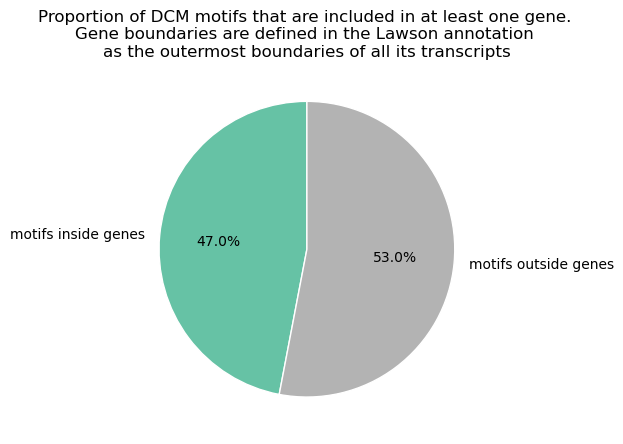

In [28]:
fig, ax = plt.subplots()
percentage=[percent_inside_gene,percent_intergenic]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["motifs inside genes","motifs outside genes"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title('Proportion of DCM motifs that are included in at least one gene. \nGene boundaries are defined in the Lawson annotation \nas the outermost boundaries of all its transcripts')


Text(0.5, 1.0, 'Proportions of genes, matching a DCM motif, that were mapped \nby a motif mapping only one gene vs. several genes')

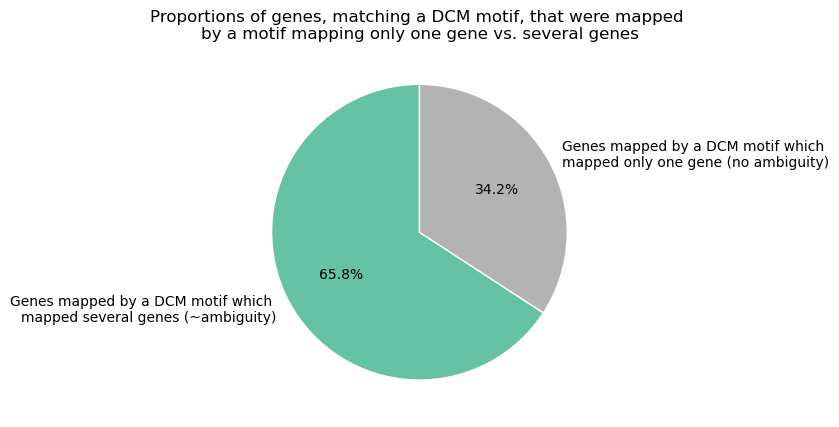

In [29]:
## Distinct genes correspond to the same motif:
fig, ax = plt.subplots()
percentage=[percent_duplicated_occurrences, percent_unique_occurrences]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Genes mapped by a DCM motif which \nmapped several genes (~ambiguity)","Genes mapped by a DCM motif which \nmapped only one gene (no ambiguity)"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title('Proportions of genes, matching a DCM motif, that were mapped \nby a motif mapping only one gene vs. several genes')

Text(0.5, 1.0, 'Proportions of DCM motifs mapping one or \nseveral genes in the genome')

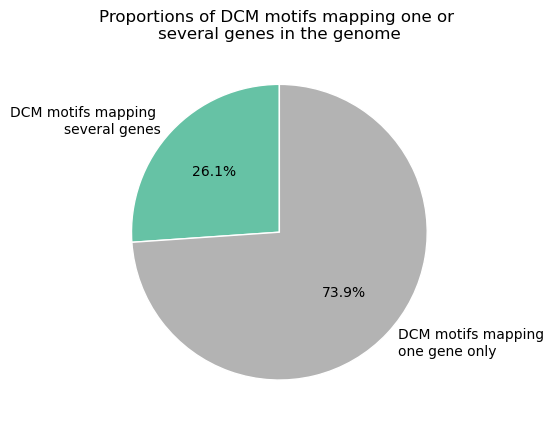

In [30]:
# Motifs matching more than one gene

fig, ax = plt.subplots()
percentage=[percent_duplicated_motifs,(100-percent_duplicated_motifs)]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["DCM motifs mapping \nseveral genes","DCM motifs mapping \none gene only"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title('Proportions of DCM motifs mapping one or \nseveral genes in the genome')


Text(0.5, 1.0, 'Proportion of DCM motifs, present in at least one gene, that are \nfound in at least one transcript or not in any transcript')

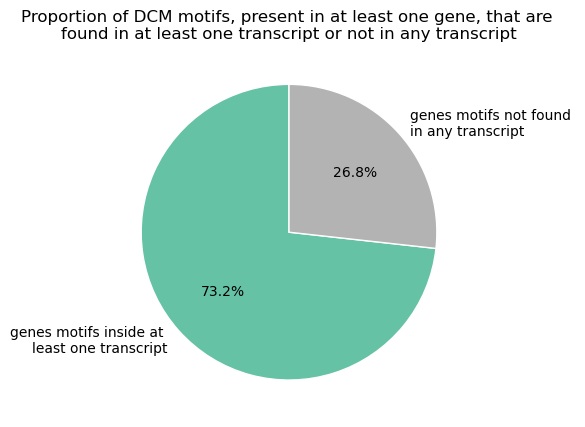

In [31]:
fig, ax = plt.subplots()
percentage=[percent_inside_transcript, percent_outside_transcript]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["genes motifs inside at \nleast one transcript","genes motifs not found \nin any transcript"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title('Proportion of DCM motifs, present in at least one gene, that are \nfound in at least one transcript or not in any transcript')


Text(0.5, 1.0, 'Proportion of DCM motifs detected in at least \none transcript that are found inside at least one exon')

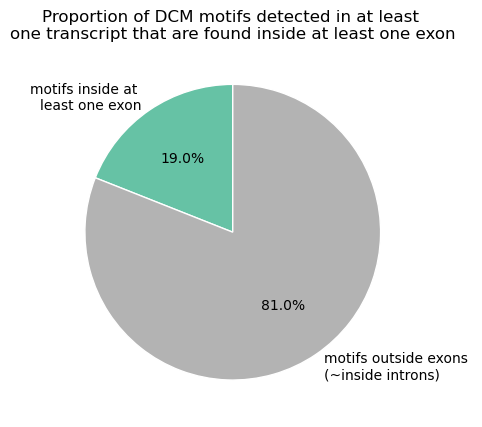

In [32]:
fig, ax = plt.subplots()
percentage=[percent_inside_exons, percent_inside_introns]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["motifs inside at \nleast one exon","motifs outside exons \n(~inside introns)"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title('Proportion of DCM motifs detected in at least \none transcript that are found inside at least one exon')